In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

x,y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.70, random_state=0)
data=pd.DataFrame(x,columns=["Feature 1","Feature 2"])
print(data.head(10))


   Feature 1  Feature 2
0   2.460233   1.142422
1   3.668009   0.155653
2   1.008301   4.172759
3   0.166942   4.850626
4   1.140699   2.058355
5  -1.590171   3.875200
6  -0.119024   2.886665
7   0.705141   4.092175
8   1.424362   3.171918
9  -1.088618   7.976496


In [13]:
scaler= StandardScaler()
x_scaled=scaler.fit_transform(data)
print(x_scaled[:5])

[[ 1.48740959 -1.06419907 -0.02473246 -1.33062236]
 [ 2.22113258 -1.43583197 -0.02473246 -1.33062236]
 [ 0.60536277  0.07707378 -0.02473246 -0.43758722]
 [ 0.0942383   0.33236937  1.34929323 -0.43758722]
 [ 0.68579422 -0.71924406 -0.02473246 -1.33062236]]


In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
cluster_labels=kmeans.fit_predict(x_scaled)
data['Cluster_labels']=cluster_labels
print(data.head(10))

   Feature 1  Feature 2  Cluster_labels
0   2.460233   1.142422               1
1   3.668009   0.155653               1
2   1.008301   4.172759               1
3   0.166942   4.850626               2
4   1.140699   2.058355               1
5  -1.590171   3.875200               2
6  -0.119024   2.886665               2
7   0.705141   4.092175               1
8   1.424362   3.171918               1
9  -1.088618   7.976496               0


Text(0, 0.5, 'WCSS')

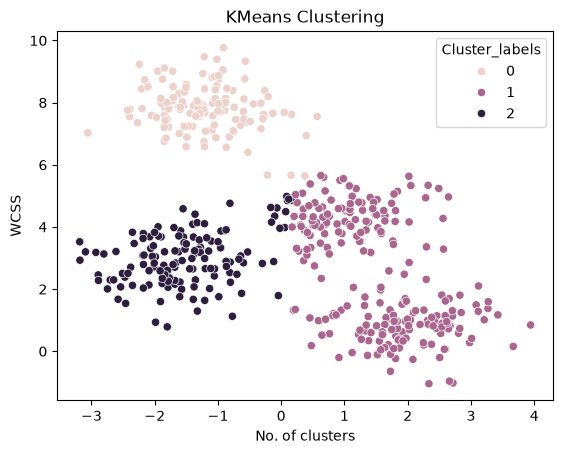

In [6]:
sns.scatterplot(data=data,x="Feature 1",y="Feature 2",hue="Cluster_labels")
plt.title("KMeans Clustering")
plt.xlabel("No. of clusters")
plt.ylabel("WCSS")

Number of clusters=1: Errors=1000.0000000000002
Number of clusters=2: Errors=456.63941878798573
Number of clusters=3: Errors=244.41852988624032
Number of clusters=4: Errors=116.47023969995755
Number of clusters=5: Errors=100.52874510297687
Number of clusters=6: Errors=89.52477649631196
Number of clusters=7: Errors=76.76438774845847
Number of clusters=8: Errors=72.69356544405962
Number of clusters=9: Errors=58.88248486598125
Number of clusters=10: Errors=54.571910067353784
Number of clusters=11: Errors=50.13871046437328


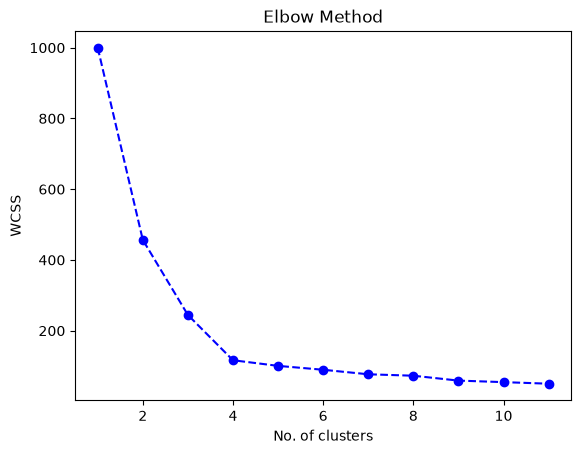

In [7]:
Errors=[]
k_values=range(1,12)

for k in k_values:
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    Errors.append(kmeans.inertia_)

plt.plot(k_values,Errors,marker="o",linestyle="--",color="b")
plt.title("Elbow Method")
plt.xlabel("No. of clusters")
plt.ylabel("WCSS")

for k,Errors in zip(k_values,Errors):
    print(f"Number of clusters={k}: Errors={Errors}")

In [8]:
kmeans_final=KMeans(n_clusters=4,random_state=42,n_init=10)
final_labels=kmeans_final.fit_predict(x_scaled)
data['Final_Cluster_labels']=final_labels

print("No. of Data points in each cluster:")
print(data['Final_Cluster_labels'].value_counts().sort_index())

No. of Data points in each cluster:
Final_Cluster_labels
0    127
1    125
2    124
3    124
Name: count, dtype: int64


Text(0, 0.5, 'Feature 2')

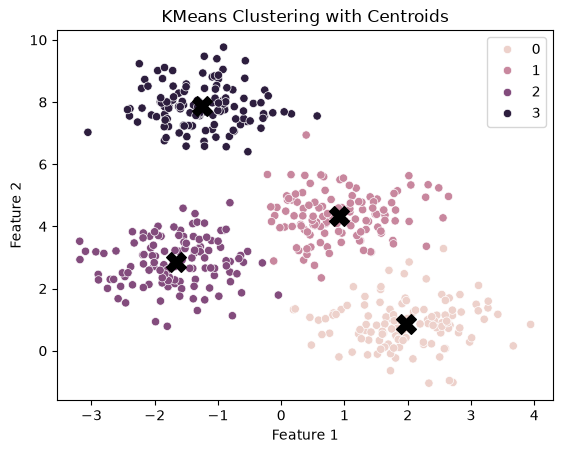

In [9]:
sns.scatterplot(data=data,x=data["Feature 1"],y=data["Feature 2"],hue=final_labels)
 
centroid_s=kmeans_final.cluster_centers_
centroid_original=scaler.inverse_transform(centroid_s)
plt.scatter(centroid_original[:,0],centroid_original[:,1],c="black",s=200,marker="X",label="Centroids")

plt.title("KMeans Clustering with Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

In [10]:
iris = pd.read_csv('Iris.csv')
df = pd.DataFrame(iris, columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"])
num_features = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(num_features)

kmeans_iris = KMeans(n_clusters=4, random_state=42)
df['Clusters'] = kmeans_iris.fit_predict(iris_scaled)

print(df['Clusters'].value_counts().sort_index())

Clusters
0    51
1    27
2    23
3    49
Name: count, dtype: int64


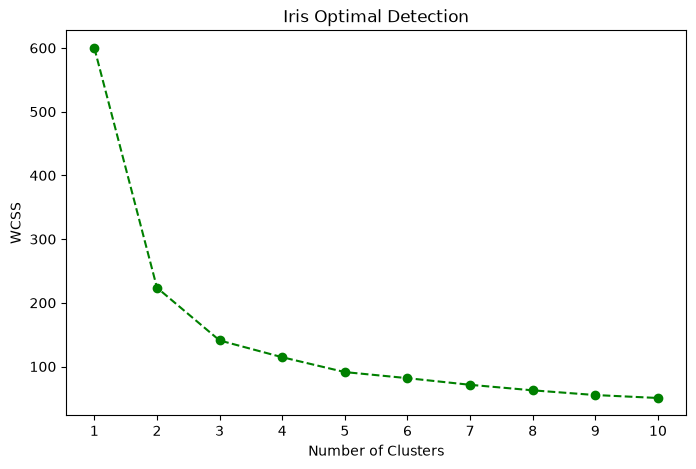

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store WCSS values
Errors = []

# Try different numbers of clusters
k_values = range(1, 11)

for k in k_values:
    model_km = KMeans(n_clusters=k, random_state=42, n_init=10)
    model_km.fit(iris_scaled)
    Errors.append(model_km.inertia_)

# Visualizing the Elbow Method
plt.figure(figsize=(8,5))
plt.plot(k_values, Errors, marker="o", linestyle="--", color="green")
plt.title("Iris Optimal Detection")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.xticks(list(k_values))
plt.show()

# Choose the optimal number of clusters
iris_optimal = 3

# Final KMeans Model
kmeans_iris_final = KMeans(
    n_clusters=iris_optimal,
    random_state=42,
    n_init=10
)

# Create cluster labels
df["Clusters"] = kmeans_iris_final.fit_predict(iris_scaled)

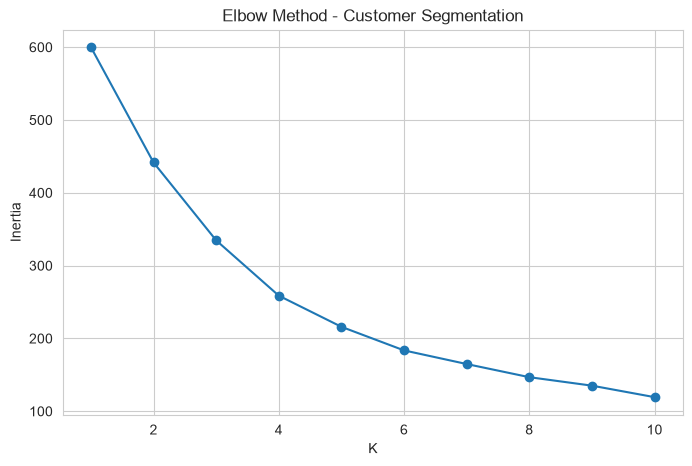

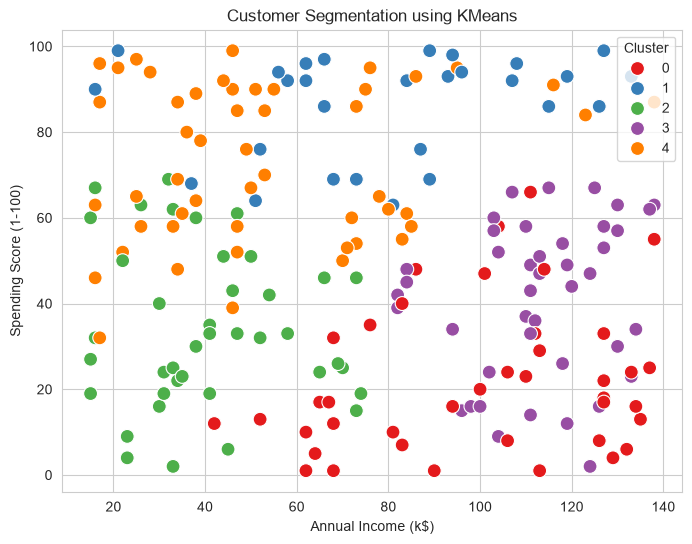

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Style
sns.set_style("whitegrid")

# Range of K values
k_range = range(1, 11)

# -----------------------------
# Step 1: Load Data
# -----------------------------
np.random.seed(42)

n_customers = 200

customer_df = pd.DataFrame({
    "CustomerID": range(1, n_customers + 1),
    "Age": np.random.randint(18, 70, n_customers),
    "Annual Income (k$)": np.random.randint(15, 140, n_customers),
    "Spending Score (1-100)": np.random.randint(1, 100, n_customers)
})

# -----------------------------
# Step 2: Scale Features
# -----------------------------
features = customer_df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
cust_scaled = scaler.fit_transform(features)

# -----------------------------
# Step 3: Elbow Method
# -----------------------------
cust_inertia = [
    KMeans(n_clusters=k, random_state=42, n_init=10)
    .fit(cust_scaled)
    .inertia_
    for k in k_range
]

plt.figure(figsize=(8,5))
plt.plot(k_range, cust_inertia, marker="o")
plt.title("Elbow Method - Customer Segmentation")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# -----------------------------
# Step 4: Final Model
# -----------------------------
kmeans_cust = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans_cust.fit_predict(cust_scaled)

# -----------------------------
# Step 5: Visualize Clusters
# -----------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segmentation using KMeans")
plt.show()